# KozyNear — Showcase Model IR

Notebook reproducible: lima model retrieval (TF-IDF, BM25, Neural MiniLM, Hybrid, **Smart**) di corpus **227 listing kos REAL** Bandar Lampung. Tiap sel dieksekusi sungguhan; output di bawah adalah hasil nyata, bukan tangkapan layar.

Mata Kuliah Temu Kembali Informasi — Universitas Lampung.

## 1. Setup: muat corpus + index + pipeline

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path(r"D:/Project TKI Kos")
sys.path.insert(0, str(ROOT / "backend"))
import pandas as pd
pd.set_option("display.max_colwidth", 46)

from app.indexing.loader import load_all_indexes
from app.indexing.hybrid import HybridIndex
from app.preprocessing import PreprocessingPipeline
from app.search.gazetteer import Gazetteer
from app.search.pipeline import smart_rank
from scripts.eval_smart import load_listings

idx = load_all_indexes(ROOT / "data" / "indexes", include_neural=True)
bm25, tfidf, neural = idx["bm25"], idx["tfidf"], idx["indobert"]
pipe = PreprocessingPipeline()
pre = lambda s: pipe.process(s).processed
hybrid = HybridIndex(bm25, neural, query_preprocessor=pre)
gz = Gazetteer.load()
listings = load_listings()
print(f"Corpus: {len(listings)} listing | vocab BM25: {len(bm25.bm25.idf)} term")
print(f"Index siap: {', '.join(idx.keys())} + smart + hybrid")

2026-06-15 12:20:28.662 | INFO     | app.indexing.loader:load_all_indexes:44 - [load] TF-IDF dari D:\Project TKI Kos\data\indexes\tfidf.pkl


2026-06-15 12:20:28.665 | INFO     | app.indexing.loader:load_all_indexes:51 - [load] BM25 dari D:\Project TKI Kos\data\indexes\bm25.pkl


2026-06-15 12:20:28.672 | INFO     | app.indexing.loader:load_all_indexes:62 - [load] IndoBERT dari D:\Project TKI Kos\data\indexes\indobert


2026-06-15 12:20:28.703 | INFO     | app.indexing.loader:load_all_indexes:67 - [load] 3 indexes loaded: ['tfidf', 'bm25', 'indobert']


Corpus: 227 listing | vocab BM25: 1498 term
Index siap: tfidf, bm25, indobert + smart + hybrid


## 2. Preprocessing 9-stage

Jargon domain (`KM Dlm`→`kamar mandi dalam`), ekstraksi harga, stemming Sastrawi — langkah demi langkah.

In [2]:
# Pipeline preprocessing 9-stage pada contoh teks (judul + deskripsi pemilik)
contoh = "Kost Putri AC KM Dlm dkt UNILA 800rb/bln, wifi kenceng"
res = pipe.process(contoh, trace=True)
print("INPUT :", res.raw)
for s in res.trace:
    out = s["output"] if isinstance(s["output"], str) else " | ".join(map(str, s["output"]))
    print(f"  {s['stage']:<20} -> {out[:70]}")
print("HASIL :", res.processed)
print("Harga terdeteksi:", res.extracted_prices)

INPUT : Kost Putri AC KM Dlm dkt UNILA 800rb/bln, wifi kenceng
  strip_html           -> Kost Putri AC KM Dlm dkt UNILA 800rb/bln, wifi kenceng
  normalize_whitespace -> Kost Putri AC KM Dlm dkt UNILA 800rb/bln, wifi kenceng
  extract_prices       -> 800000
  lowercase            -> kost putri ac km dlm dkt unila 800rb/bln, wifi kenceng
  apply_jargon_dict    -> kost putri air conditioner kamar mandi dalam dkt universitas lampung 8
  correct_spelling     -> kost putri air conditioner kamar mandi dalam dkt universitas lampung 8
  tokenize             -> kost | putri | air | conditioner | kamar | mandi | dalam | dkt | unive
  remove_stopwords     -> putri | air | conditioner | mandi | dkt | universitas | lampung | 800r
  stem                 -> putri | air | conditioner | mandi | dkt | universitas | lampung | 800r
HASIL : putri air conditioner mandi dkt universitas lampung 800rb bulan wifi kenceng
Harga terdeteksi: [800000]


## 3. Lima model pada satu query

`"kos putri dekat unila wifi murah"` — bandingkan judul top-5 tiap model.

In [3]:
# Bandingkan lima model pada satu query natural language
q = "kos putri dekat unila wifi murah"

def top(model, n=5):
    if model == "bm25":   ids = [(h.doc_id, h.score) for h in bm25.query(pre(q), top_k=n)]
    elif model == "tfidf":ids = [(h.doc_id, h.score) for h in tfidf.query(pre(q), top_k=n)]
    elif model == "neural":ids = [(h.doc_id, h.score) for h in neural.query(q, top_k=n)]
    elif model == "hybrid":ids = [(h.doc_id, h.score) for h in hybrid.query(q, top_k=n)]
    else: ids = smart_rank(q, bm25, listings, gz, top_k=n, preprocess=pre)[0]
    return [listings[i].judul for i, _ in ids]

pd.DataFrame({m: top(m) for m in ["bm25","tfidf","neural","hybrid","smart"]})

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]

,bm25,tfidf,neural,hybrid,smart
0,Kost Pondok Maimun Kedaton Bandar Lampung,Kost Mutiara Kedaton Bandar Lampung,Kost Istiqomah Kedaton Bandar Lampung,Kost Pondok Maimun Kedaton Bandar Lampung,Kost Executive Class Unila Bandar Lampung
1,Kost Executive Class Unila Bandar Lampung,Kost Agape Kedaton Bandar Lampung,Kost Dhe House Sukarame Bandar Lampung,Kost Executive Class Unila Bandar Lampung,Kost Unila Kedaton Bandar Lampung
2,Kost Fortuna Gedong Meneng Rajabasa Bandar...,Kost Fortuna Gedong Meneng Rajabasa Bandar...,Kost Wisma Rezhyg Sukarame Bandar Lampung,Kost Fortuna Gedong Meneng Rajabasa Bandar...,Kost Agape Kedaton Bandar Lampung
3,Kost Mutiara Kedaton Bandar Lampung,Kost Griya Rose Rajabasa Bandar Lampung,Rumah Kontrakan Unila Amanda Kedaton Banda...,Kost Mutiara Kedaton Bandar Lampung,Kost Kinasih 88 Kampung Baru Unila Labuhan...
4,Kost Agape Kedaton Bandar Lampung,Kost Dhe House Sukarame Bandar Lampung,Kost Four Way Halim Bandar Lampung,Kost Dhe House Sukarame Bandar Lampung,Kost Widefi Unila Tipe B Rajabasa Bandar L...


## 4. Smart pipeline (model live)

Memecah query jadi constraint terstruktur (gender/harga/fasilitas/anchor), lalu fusi teks + geo + atribut dengan hard filter.

In [4]:
# Smart pipeline: query understanding + geo + fusion (model live)
res, understood, relaxed = (lambda r: (r[0], r[1], r[2]))(
    smart_rank(q, bm25, listings, gz, top_k=5, preprocess=pre))
print("Yang dipahami sistem dari query:")
for k, v in understood.items():
    if v: print(f"  {k:<10}: {v}")
print("\nTop-5 smart:")
for did, score in res:
    r = listings[did]
    print(f"  [{r.tipe:<6} Rp{r.harga_per_bulan:>8} {(r.kecamatan or '-'):<14}] {r.judul[:44]}")

Yang dipahami sistem dari query:
  gender    : putri
  harga_max : 1000000
  fasilitas : ['wifi']
  anchor    : universitas lampung

Top-5 smart:
  [putri  Rp 1000000 Kedaton       ] Kost Executive Class Unila Bandar Lampung
  [putri  Rp  600000 Kedaton       ] Kost Unila Kedaton Bandar Lampung
  [putri  Rp  600000 Kedaton       ] Kost Agape Kedaton Bandar Lampung
  [putri  Rp  750000 Labuhan Ratu  ] Kost Kinasih 88 Kampung Baru Unila Labuhan R
  [putri  Rp 1000000 Rajabasa      ] Kost Widefi Unila Tipe B Rajabasa Bandar Lam


## 5. Evaluasi 30 query — metrik standard

MAP, P@K, NDCG, MRR per model.

In [5]:
# Hasil evaluasi 30 query (dibaca dari CSV hasil eksperimen)
df = pd.read_csv(ROOT / "eval" / "results.csv")
agg = (df.groupby("model")[["p_at_5","p_at_10","ap","ndcg_at_10","rr"]]
         .mean().round(3).sort_values("ap", ascending=False))
agg.columns = ["P@5","P@10","MAP","NDCG@10","MRR"]
agg

,P@5,P@10,MAP,NDCG@10,MRR
model,,,,,
smart,0.773,0.633,0.359,0.684,0.863
bm25,0.640,0.610,0.296,0.634,0.872
hybrid,0.640,0.600,0.285,0.626,0.872
tfidf,0.613,0.547,0.253,0.569,0.786
indobert,0.180,0.150,0.044,0.154,0.359


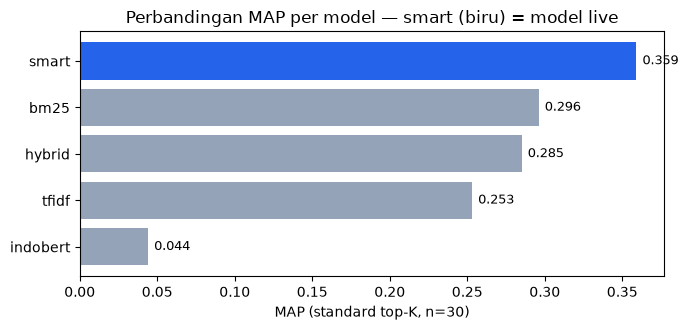

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.4))
order = agg.sort_values("MAP")
colors = ["#2563eb" if m == "smart" else "#94a3b8" for m in order.index]
ax.barh(order.index, order["MAP"], color=colors)
ax.set_xlabel("MAP (standard top-K, n=30)"); ax.set_title("Perbandingan MAP per model — smart (biru) = model live")
for i, v in enumerate(order["MAP"]): ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Constraint Satisfaction @5 (lensa kebutuhan user)

Bebas pooling bias: mengukur apakah hasil benar-benar memenuhi gender + budget + fasilitas + jarak kampus.

In [7]:
# Constraint Satisfaction @5: % top-5 yang penuhi SEMUA kebutuhan user
# (gender + budget + fasilitas + radius 3km kampus) — bebas pooling bias
cs = pd.read_csv(ROOT / "eval" / "results_constraints.csv")
cols = [c for c in cs.columns if c.startswith("cs_at_5_")]
cs_mean = cs[cols].mean().round(3).sort_values(ascending=False)
cs_mean.index = [c.replace("cs_at_5_","") for c in cs_mean.index]
cs_mean.to_frame("mean CS@5 (n=30)")

,mean CS@5 (n=30)
smart,0.867
bm25,0.527
tfidf,0.527
hybrid,0.513
indobert,0.233


## 7. Eksperimen pendukung

Ablation preprocessing & kuantifikasi pooling bias.

In [8]:
# Ringkasan eksperimen lain (dibaca dari artefak eval)
import json
abl = pd.read_csv(ROOT / "eval" / "preprocess_ablation.csv")[["config","map","delta_map"]]
pb = json.loads((ROOT / "eval" / "explore_pooling_bias.json").read_text())["per_model"]
print("Ablation preprocessing (delta MAP saat stage dimatikan):")
print(abl.to_string(index=False))
print("\nPooling bias — MAP saat pool adil (5 model) vs BM25-only:")
for m, d in pb.items():
    print(f"  {m:<8} {d['map_bm25pool']:.3f} -> {d['map_unionpool']:.3f}  (delta {d['delta']:+.3f})")

Ablation preprocessing (delta MAP saat stage dimatikan):
                    config    map  delta_map
     full (semua stage ON) 0.2958     0.0000
          tanpa strip_html 0.2958     0.0000
tanpa normalize_whitespace 0.2958     0.0000
           tanpa lowercase 0.2958     0.0000
   tanpa apply_jargon_dict 0.3193     0.0235
    tanpa correct_spelling 0.2956    -0.0002
    tanpa remove_stopwords 0.2885    -0.0073
                tanpa stem 0.2969     0.0011

Pooling bias — MAP saat pool adil (5 model) vs BM25-only:
  bm25     0.296 -> 0.236  (delta -0.059)
  tfidf    0.253 -> 0.229  (delta -0.024)
  neural   0.044 -> 0.107  (delta +0.064)
  hybrid   0.285 -> 0.230  (delta -0.054)
  smart    0.359 -> 0.431  (delta +0.072)


## Kesimpulan

**Smart** unggul di MAP standard (0.359) dan dominan di CS@5 (0.867 vs BM25 0.527, p=0.0001) tanpa model neural di runtime. Skor standard cenderung meremehkan smart karena *pooling bias* (lihat sel 7): saat pool dibuat adil, jarak smart vs BM25 makin lebar. Detail metodologi di `LAPORAN.md`.